# Kaggle Playground Series - S6E3: Predict Customer Churn

## Yarışma Özeti
Bu proje, Kaggle'ın 2026 yılı Playground Serisi'nin (Sezon 6, Bölüm 3) bir parçasıdır. Temel amacımız, telekomünikasyon müşterilerinin hizmetlerini iptal etme (churn) olasılıklarını tahmin etmektir. 

* **Hedef Değişken:** `Churn` (Müşteri ayrılacak mı?)
* **Değerlendirme Metriği:** Modelin başarısı, ROC eğrisi altındaki alan (**AUC**) metriği ile ölçülecektir. Sınıflandırma eşiğinden ziyade, modelin riskli müşterileri ne kadar iyi sıraladığına odaklanacağız.
* **Veri Seti Bağlamı:** Yarışma verisi, popüler IBM Telco Customer Churn veri seti kullanılarak eğitilmiş bir derin öğrenme modeli ile sentetik olarak üretilmiştir. Sentetik olmasına rağmen gerçek dünya verisinin (feature) dağılımlarını yansıtmaktadır.

In [4]:
# Gerekli temel kütüphaneleri içe aktarıyoruz
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# ADIM 1: Veriyi Yükleme
# ---------------------------------------------------------
# Not: Notebook 'notebooks' klasöründe çalıştığı için, '../' ile bir üst dizine çıkıp 'data/raw' içine giriyoruz.
TRAIN_PATH = "../Data/raw/train.csv"

print("Eğitim verisi yükleniyor...")
# 'id' sütununu direkt index olarak ayarlıyoruz, böylece modellemeye girerken bize ayak bağı olmaz.
train_df = pd.read_csv(TRAIN_PATH, index_col='id')

# ---------------------------------------------------------
# ADIM 2: Veriye İlk Bakış (Head)
# ---------------------------------------------------------
print("\n--- 1. Veri Setinin İlk 5 Satırı ---")
display(train_df.head()) 

# ---------------------------------------------------------
# ADIM 3: Veri Seti Yapısı ve Tipleri (Info)
# ---------------------------------------------------------
print("\n--- 2. Veri Seti Yapısı ve Değişken Tipleri ---")
# train_df.info() fonksiyonu veri tiplerini (int, float, object) ve bellek kullanımını gösterir.
train_df.info()

# ---------------------------------------------------------
# ADIM 4: Eksik Veri (Null) Kontrolü
# ---------------------------------------------------------
print("\n--- 3. Eksik Değer Kontrolü ---")
# Hangi sütunda toplam kaç adet eksik veri (NaN) olduğunu topluyoruz.
missing_values = train_df.isnull().sum()
print(missing_values[missing_values > 0]) # Sadece eksik veri olan sütunları ekrana yazdırır.
# Eğer çıktı boş dönüyorsa "Eksik veri yok" demektir.

Eğitim verisi yükleniyor...

--- 1. Veri Setinin İlk 5 Satırı ---


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
id,,,,,,,,,,,,,,,,,,,,
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes



--- 2. Veri Seti Yapısı ve Değişken Tipleri ---
<class 'pandas.core.frame.DataFrame'>
Index: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194

1. Sıfır Eksik Veri (Null): En iyi senaryo! Series([], dtype: int64) çıktısı veri setinde NaN (boş) değer olmadığını gösteriyor. Eksik veri doldurma (imputation) adımıyla vakit kaybetmeyeceğiz.

2. Veri Tipi Dağılımı: Yaklaşık 600 bin satırımız (594.194) ve 20 sütunumuz var. Sütunların büyük bir çoğunluğu object yani metin/kategorik tipinde (Örn: Yes/No, Male/Female, DSL/Fiber optic).

3. Makine Öğrenmesi Engeli: Veritabanı sorgularında veya tablo tasarımlarında metin tutmak sorun yaratmazken, makine öğrenmesi modelleri sadece ve sadece sayılarla çalışır.

Bu noktada profesyonel bir veri bilimci refleksi gösterip hemen "Feature Encoding" (Öznitelik Kodlama) stratejisi kurgulamamız gerekiyor.

In [5]:
# ---------------------------------------------------------
# ADIM 5: Sütun Tiplerini Ayırma ve "Gizli" Hataları Düzeltme
# ---------------------------------------------------------
print("\n--- 4. Değişken Sınıflandırması ---")

# Orijinal Telco veri setlerinde TotalCharges bazen string (object) olarak gelir. 
# Eğer bu veri setinde de varsa, onu zorla (coerce) sayısal tipe çeviriyoruz.
if 'TotalCharges' in train_df.columns and train_df['TotalCharges'].dtype == 'object':
    print("⚠️ TotalCharges 'object' olarak yakalandı, 'float' tipine dönüştürülüyor...")
    # 'errors=coerce' parametresi, dönüştürülemeyen boşlukları NaN yapar.
    train_df['TotalCharges'] = pd.to_numeric(train_df['TotalCharges'], errors='coerce')
    # Oluşan az sayıdaki NaN değeri 0 ile doldurabiliriz (genelde yeni müşterilerdir)
    train_df['TotalCharges'].fillna(0, inplace=True)

# Kategorik (object) ve Sayısal (int, float) sütunları otomatik ayıralım
# Hedef değişkenimiz olan 'Churn' sütununu (eğer varsa) bu listeden çıkarıyoruz.
target_col = 'Churn'

categorical_cols = [col for col in train_df.columns if train_df[col].dtype == 'object' and col != target_col]
numerical_cols = [col for col in train_df.columns if train_df[col].dtype in ['int64', 'float64'] and col != target_col]

print(f"Kategorik Sütun Sayısı: {len(categorical_cols)}")
print(f"Sayısal Sütun Sayısı: {len(numerical_cols)}")

# ---------------------------------------------------------
# ADIM 6: Hedef Değişken (Churn) Analizi
# ---------------------------------------------------------
print("\n--- 5. Hedef Değişken (Churn) Dağılımı ---")
if target_col in train_df.columns:
    churn_counts = train_df[target_col].value_counts()
    churn_ratios = train_df[target_col].value_counts(normalize=True) * 100
    
    # Şık bir DataFrame formatında gösterelim
    target_summary = pd.DataFrame({
        'Kişi Sayısı': churn_counts,
        'Yüzde (%)': churn_ratios.round(2)
    })
    display(target_summary)
else:
    print("HATA: Hedef değişken (Churn) eğitim veri setinde bulunamadı!")


--- 4. Değişken Sınıflandırması ---
Kategorik Sütun Sayısı: 15
Sayısal Sütun Sayısı: 4

--- 5. Hedef Değişken (Churn) Dağılımı ---


,Kişi Sayısı,Yüzde (%)
Churn,,
No,460377,77.48
Yes,133817,22.52


1. Sınıf Dengesizliği (Class Imbalance): Müşterilerin yaklaşık %77'si kalmış, %22'si ayrılmış (Churn = Yes). Bu durum sektördeki müşteri kayıp analizlerinde çok tipik bir senaryodur. Sınıflar dengesiz olduğu için "accuracy" (doğruluk) metriği bizi yanıltabilirdi, neyse ki yarışma bizden bunu AUC metriği ile ölçmemizi istiyor (AUC bu duruma çok daha dirençlidir). Ancak modeli eğitirken çapraz doğrulama (cross-validation) yaparken kesinlikle Stratified K-Fold kullanmamız gerekecek ki eğitim setlerimizin her birinde bu %77-%22 oranı korunsun.

2. Kategorik Ağırlık: 15 tane kategorik değişkenimiz var. Demek ki yarışma forumunda yarışmacıların konuştuğu "Target Encoding" veya "Optimal Binning" gibi yöntemler bu işin kaderini belirleyecek. Kategorik verileri sayısala dönüştürmek, bu veri setindeki en büyük işimiz olacak.


--- 6. Keşifçi Veri Analizi (EDA) Grafikleri Çiziliyor ---


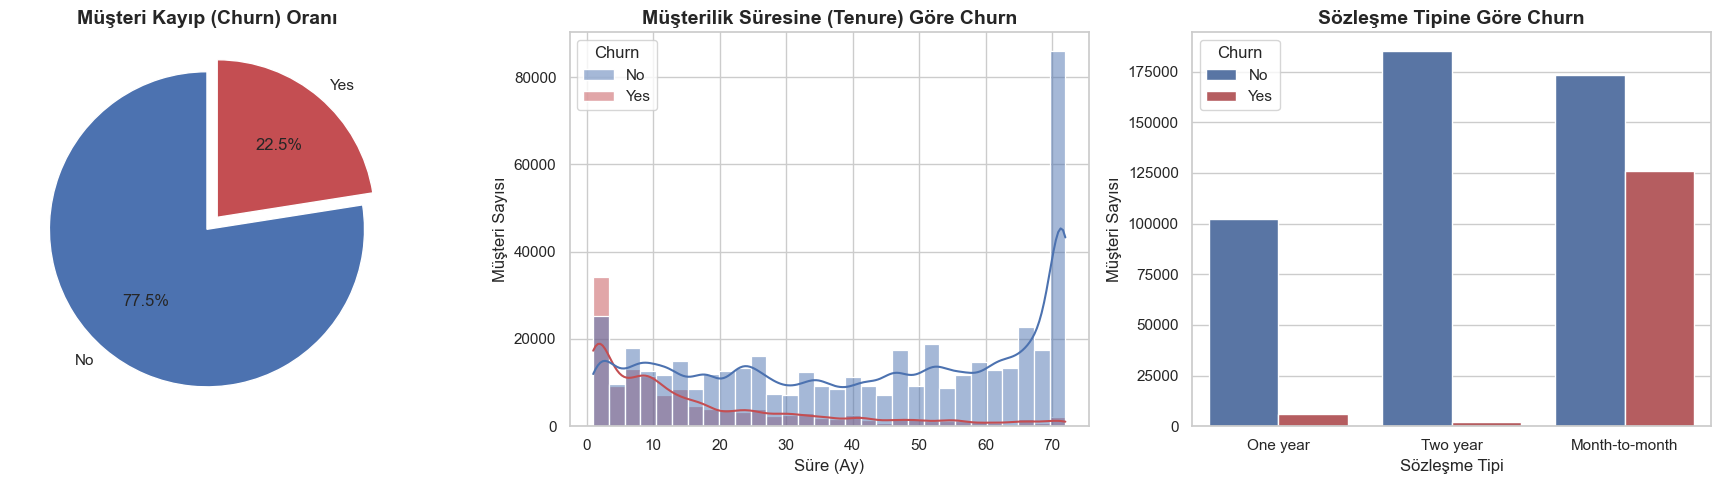

In [6]:
# Gerekli görselleştirme kütüphanelerini ekliyoruz
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklerin genel stilini kurumsal bir görünüme ayarlayalım
sns.set_theme(style="whitegrid", palette="muted")

# ---------------------------------------------------------
# ADIM 7: EDA - Temel Görselleştirmeler
# ---------------------------------------------------------
print("\n--- 6. Keşifçi Veri Analizi (EDA) Grafikleri Çiziliyor ---")

# 3'lü bir grafik alanı (figure) oluşturuyoruz, geniş ve okunaklı olacak
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Renk paletimiz: Kalanlar için Mavi, Ayrılanlar için Kırmızımsı
custom_palette = {'No': '#4C72B0', 'Yes': '#C44E52'}

# 1. Hedef Değişken Dağılımı (Kapsamlı Pasta Grafiği)
churn_counts = train_df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=['#4C72B0', '#C44E52'], explode=[0, 0.1])
axes[0].set_title("Müşteri Kayıp (Churn) Oranı", fontsize=14, fontweight='bold')

# 2. Sayısal Değişken Örneği: 'tenure' (Müşterilik Süresi) vs Churn
# tenure: Müşterinin kaç aydır bu şirketten hizmet aldığı
sns.histplot(data=train_df, x='tenure', hue='Churn', kde=True, ax=axes[1], bins=30, palette=custom_palette)
axes[1].set_title("Müşterilik Süresine (Tenure) Göre Churn", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Süre (Ay)")
axes[1].set_ylabel("Müşteri Sayısı")

# 3. Kategorik Değişken Örneği: 'Contract' (Sözleşme Tipi) vs Churn
sns.countplot(data=train_df, x='Contract', hue='Churn', ax=axes[2], palette=custom_palette)
axes[2].set_title("Sözleşme Tipine Göre Churn", fontsize=14, fontweight='bold')
axes[2].set_xlabel("Sözleşme Tipi")
axes[2].set_ylabel("Müşteri Sayısı")

plt.tight_layout()
plt.show()

1. Süre (Tenure) Grafiği: Müşteriler en çok ilk aylarda (özellikle 0-10 ay arası) iptal ediyor (kırmızı çizginin zirve yaptığı yer). Ancak belli bir süreyi atlatanlar sisteme sadık kalıyor (sağdaki devasa mavi yığılma).

2. Sözleşme Tipi Grafiği: "Aydan aya" (Month-to-month) sözleşme yapanlarda kayıp oranı tavan yapmış. 1 veya 2 yıllık uzun taahhüt verenler ise çok daha güvenli.